# Phase 2 — Data Acquisition & Exploratory Data Analysis

**Dataset:** Gene Expression Cancer RNA-Seq (UCI / TCGA)  
**Samples:** 801 patients | **Features:** 20,531 genes  
**Classes (eval only):** BRCA, KIRC, COAD, LUAD, PRAD

## 0. Imports

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FIGURES_DIR  = "../reports/figures"
DATA_PATH    = "../data/data.csv"
LABELS_PATH  = "../data/labels.csv"
os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

## 1. Data Acquisition

Download once via `ucimlrepo` and save to `data/data.csv` (gitignored).  
Skip the cell if the file already exists.

In [7]:
if not os.path.exists(DATA_PATH):
    from ucimlrepo import fetch_ucirepo
    print("Downloading dataset from UCI...")
    ds = fetch_ucirepo(id=401)
    df_raw = ds.data.original
    df_raw.to_csv(DATA_PATH, index=False)
    print(f"Saved to {DATA_PATH}  ({df_raw.shape[0]} rows x {df_raw.shape[1]} cols)")
else:
    print(f"Data file already exists: {DATA_PATH}")

Data file already exists: ../data/data.csv


## 2. Load Data

In [8]:
X      = pd.read_csv(DATA_PATH, index_col=0)
labels = pd.read_csv(LABELS_PATH, index_col=0)["Class"]

print(f"Feature matrix : {X.shape[0]} samples x {X.shape[1]} genes")
print(f"Label column   : {labels.nunique()} unique classes")
X.head(3)

Feature matrix : 801 samples x 20531 genes
Label column   : 5 unique classes


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0


## 3. Basic Inspection

In [9]:
# --- Missing values ---
n_missing = X.isnull().sum().sum()
print(f"Missing values in feature matrix: {n_missing}")

# --- Data types ---
print(f"\nDtype counts:")
print(X.dtypes.value_counts())

# --- Expression value range ---
print(f"\nExpression value range: [{X.values.min():.3f}, {X.values.max():.3f}]")
print(f"Overall mean : {X.values.mean():.4f}")
print(f"Overall std  : {X.values.std():.4f}")

Missing values in feature matrix: 0

Dtype counts:
float64    20531
Name: count, dtype: int64

Expression value range: [0.000, 20.779]
Overall mean : 6.4433
Overall std  : 4.0582


## 4. Label Distribution

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78


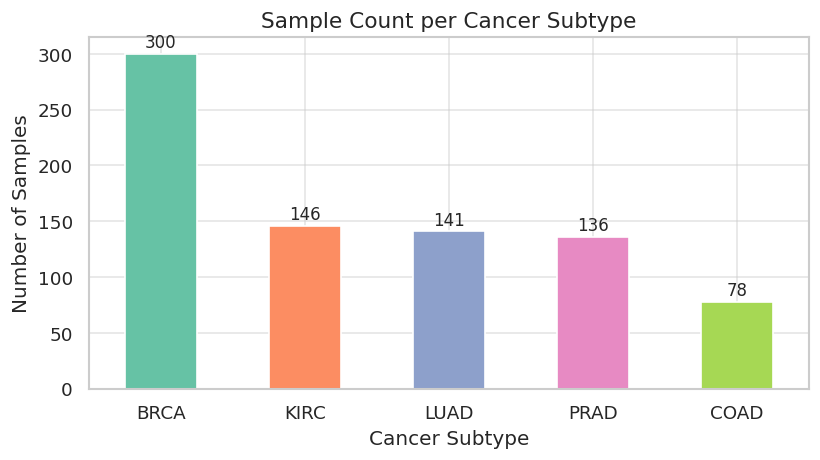

In [10]:
label_counts = labels.value_counts()
print(label_counts.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
label_counts.plot(kind="bar", ax=ax, edgecolor="white", color=sns.color_palette("Set2", len(label_counts)))
ax.set_title("Sample Count per Cancer Subtype", fontsize=13)
ax.set_xlabel("Cancer Subtype")
ax.set_ylabel("Number of Samples")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            int(bar.get_height()), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/label_distribution.png")
plt.show()

## 5. Expression Value Distribution

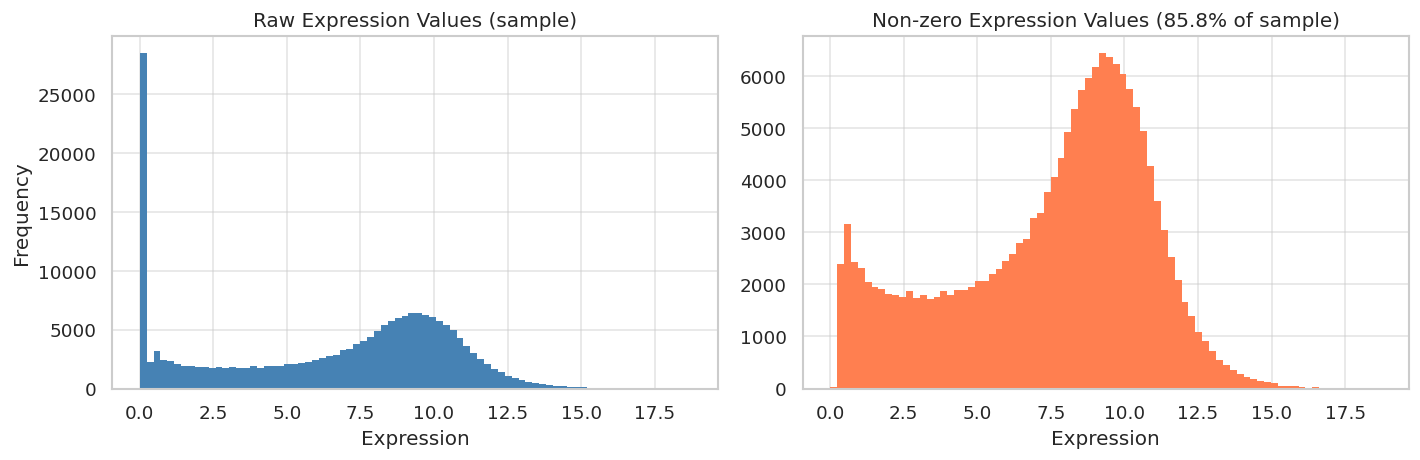

Fraction of zero values: 14.2%


In [11]:
# Flatten a random sample of values for plotting speed
flat_sample = X.values.flatten()
flat_sample = flat_sample[np.random.choice(len(flat_sample), size=200_000, replace=False)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(flat_sample, bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("Raw Expression Values (sample)")
axes[0].set_xlabel("Expression")
axes[0].set_ylabel("Frequency")

# Many values are zero or near-zero; look at non-zero values
nonzero = flat_sample[flat_sample > 0]
axes[1].hist(nonzero, bins=80, color="coral", edgecolor="none")
axes[1].set_title(f"Non-zero Expression Values ({len(nonzero)/len(flat_sample)*100:.1f}% of sample)")
axes[1].set_xlabel("Expression")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/expression_distribution.png")
plt.show()

print(f"Fraction of zero values: {(flat_sample == 0).mean()*100:.1f}%")

## 6. Per-Gene Variance Analysis

In [12]:
gene_var = X.var(axis=0)

n_zero_var = (gene_var == 0).sum()
n_low_var  = (gene_var < 0.01).sum()
print(f"Zero-variance genes : {n_zero_var}")
print(f"Low-variance genes (var < 0.01): {n_low_var}")
print(f"\nVariance stats:")
print(gene_var.describe())

Zero-variance genes : 267
Low-variance genes (var < 0.01): 564

Variance stats:
count    20531.000000
mean         1.764138
std          2.574352
min          0.000000
25%          0.343816
50%          0.801383
75%          2.173090
max         44.763849
dtype: float64


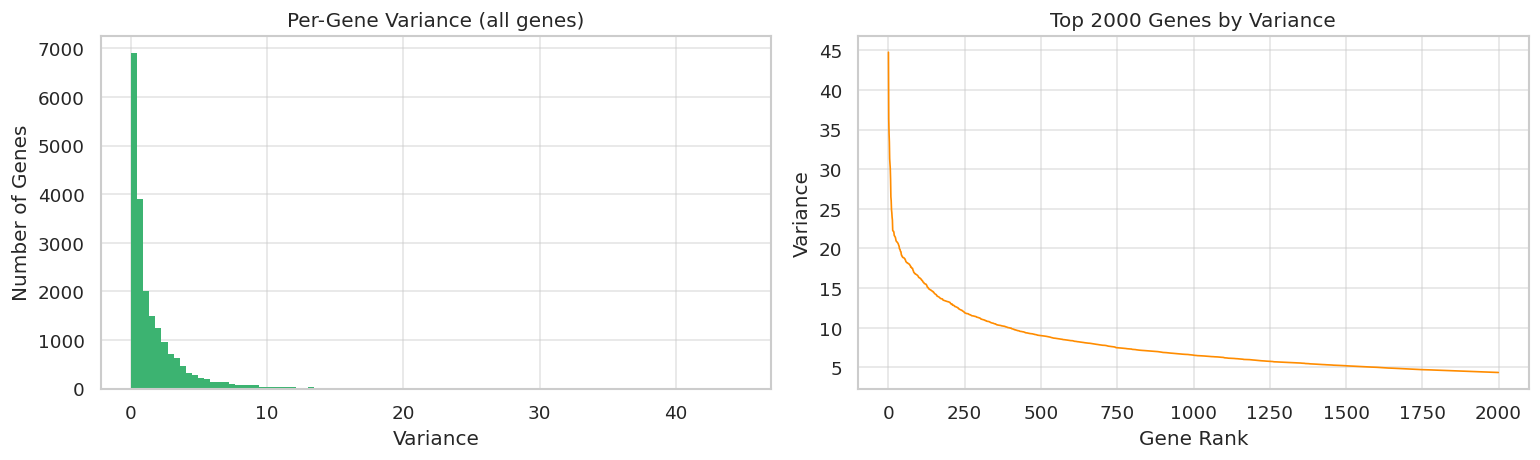

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full variance distribution
axes[0].hist(gene_var, bins=100, color="mediumseagreen", edgecolor="none")
axes[0].set_title("Per-Gene Variance (all genes)")
axes[0].set_xlabel("Variance")
axes[0].set_ylabel("Number of Genes")

# Top 2000 highest-variance genes
top_var = gene_var.nlargest(2000)
axes[1].plot(np.arange(len(top_var)), top_var.values, color="darkorange", linewidth=1)
axes[1].set_title("Top 2000 Genes by Variance")
axes[1].set_xlabel("Gene Rank")
axes[1].set_ylabel("Variance")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/gene_variance.png")
plt.show()

## 7. Mean Expression per Cancer Subtype (Top 20 Most Variable Genes)

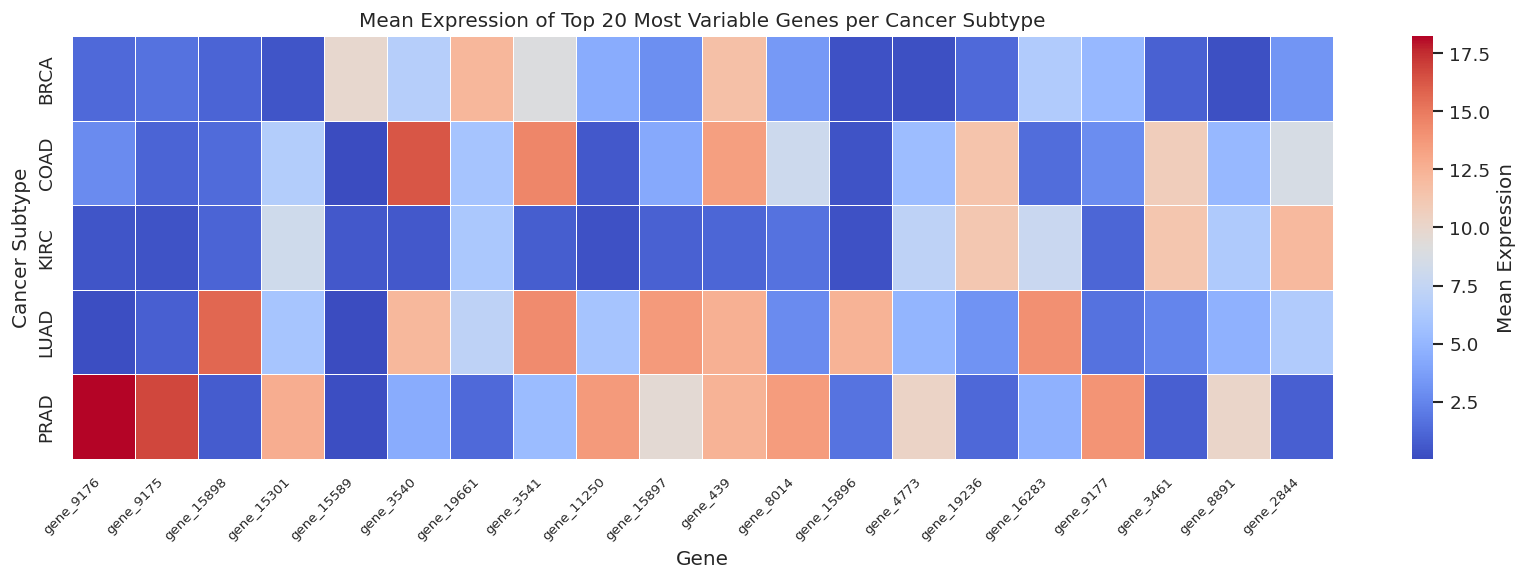

In [14]:
top20_genes = gene_var.nlargest(20).index.tolist()
df_top20 = X[top20_genes].copy()
df_top20["Class"] = labels.values

mean_by_class = df_top20.groupby("Class")[top20_genes].mean()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(mean_by_class, ax=ax, cmap="coolwarm", linewidths=0.3,
            cbar_kws={"label": "Mean Expression"})
ax.set_title("Mean Expression of Top 20 Most Variable Genes per Cancer Subtype")
ax.set_xlabel("Gene")
ax.set_ylabel("Cancer Subtype")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/heatmap_top20_genes.png")
plt.show()

## 8. EDA Summary

| Property | Value |
|---|---|
| Samples | 801 |
| Genes | 20,531 |
| Missing values | 0 |
| Zero-variance genes | (see above) |
| Dominant value | 0.0 (sparse expression) |

**Key observations:**
- Expression data is highly sparse — a large fraction of values are exactly 0.
- Many genes have near-zero variance and can be safely removed before PCA.
- The five cancer subtypes show distinct mean expression patterns on the top variable genes, suggesting the signal for clustering is present.
- A log-transform (`log1p`) will be applied in Phase 3 to reduce right-skew before standardization.